# SAMI — Notebook 3 · Emergent themes & emotion (NLP)

**NLP only.** This notebook discovers the semantic structure of the messages
automatically and contrasts it with the official MMC taxonomy: KMeans over
sentence embeddings (primary) and lemmatized TF-IDF (comparison), the
cluster-vs-taxonomy agreement, the **emergent themes** the 7 categories do not
capture, the qualitative voices of users, per-message **sentiment** as an
unsolicited distress signal, and a closing **geographic synthesis** of need +
tone by city.

*Descriptive cross-cuts by category live in Notebook 2.*

---

### Objectives
- Discover the semantic sub-themes of the messages automatically and contrast
  them with the 7 official MMC categories.
- Detect **emergent themes** the official taxonomy does not capture.
- Surface qualitative voices: a word cloud + a thematic read of comments.
- Measure the emotional tone of messages as a signal of unsolicited distress.
- Synthesize geographically where the greatest need concentrates.

### Guiding questions
1. Do the automatic clusters confirm the official MMC categories?
2. Which needs, not contemplated by the taxonomy, appear anyway?
3. How negative or positive is the tone of messages, and does it vary by category?
4. Where does the most urgent need concentrate geographically, together with
   emotional distress?

### Hypotheses
- **H1.** Most clusters coincide reasonably with the 7 MMC categories.
- **H2.** There are 2–4 real emergent themes (not noise) the taxonomy misses.
- **H3.** The predominant tone is neutral-negative, concentrated in
  regularization / legal categories.
- **H4.** Emotional distress concentrates in specific cities, coinciding with
  high demand for legal documentation.


## 0. Setup, data & original classification

In [1]:
# Imports. Collapsed on purpose -- no analysis here.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter
from wordcloud import WordCloud

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = 0 if DEVICE == "cuda" else -1

In [2]:
# Temporary neutral styling -- brand palette removed; matplotlib defaults for now.
# These names shadow the old palette so moved cells run unchanged. Re-add the
# real palette later by replacing THIS cell (nothing else references the brand).
_CYCLE = plt.rcParams["axes.prop_cycle"].by_key()["color"]   # matplotlib defaults
PRIMARY = _CYCLE[0]
BLUE_SEQ = BLUES = _CYCLE
EARTH    = _CYCLE
CAT      = _CYCLE
AGUA, ARBOL, AMEBA, MADERA, HONGO, NEGRO = (
    _CYCLE[0], _CYCLE[2], _CYCLE[4], _CYCLE[1], "#dddddd", "black")
INK = INK2 = "black"
MUTED = "gray"
GRID  = "#cccccc"
SURFACE = "white"

def cat_colors(n):
    return [_CYCLE[i % len(_CYCLE)] for i in range(n)]

def bar_colors(n):
    return [_CYCLE[i % len(_CYCLE)] for i in range(n)]

def seq_colors(n):
    return [_CYCLE[0]] * n

def pct_count_autopct(values, min_pct=3.0):
    total = float(sum(values))
    def _fmt(pct):
        if pct < min_pct:
            return ""
        return f"{pct:.1f}%\n({int(round(pct/100*total))})"
    return _fmt

In [3]:
# Data loaders -- inlined so the notebook is fully self-contained (no external module).
import re, unicodedata

DATA_DIR = "../data_&_docs"
RESPONSES_PATH = DATA_DIR + "/MMC_bot_responses_1783087815.xlsx"
MEAL_PATH = DATA_DIR + "/MMC_MEAL_1783087939.xlsx"
DATA_HEADER_ROW = 2  # header is the 3rd row of the export

def _phone(name):
    return re.sub(r"\D", "", str(name))

_CITY_CANON = {
    "medellin": "Medellín", "medellin antioquia": "Medellín", "belen": "Medellín",
    "bogota": "Bogotá", "bogota dc": "Bogotá",
    "cucuta": "Cúcuta",
    "barranquilla": "Barranquilla",
    "santa marta": "Santa Marta",
    "cali": "Cali",
    "cartagena": "Cartagena",
    "bucaramanga": "Bucaramanga",
    "ipiales": "Ipiales",
    "riohacha": "Riohacha", "maicao": "Maicao",
    "soacha": "Soacha", "soacha cundinamarca": "Soacha",
    "necocli": "Necoclí",
}
_NON_CITY = {"colombia", "cundinamarca", "antioquia", "otra", "nan"}

def _fold(s):
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(c for c in s if not unicodedata.combining(c))
    return s.strip().lower()

def city_canon(name):
    if name is None:
        return "Otra"
    key = _fold(name)
    if key in _NON_CITY or key == "":
        return "Otra"
    if key in _CITY_CANON:
        return _CITY_CANON[key]
    for k, v in _CITY_CANON.items():
        if key.startswith(k):
            return v
    return "Otra"

def clean_city(raw_city, city_other):
    raw = ("" if raw_city is None else str(raw_city)).strip()
    other = "" if city_other is None or pd.isna(city_other) else str(city_other).strip()
    if raw == "Otra" and other:
        return other.title()
    return raw

def _read_whatsapp(path):
    d = pd.read_excel(path, header=DATA_HEADER_ROW)
    d = d[d["Name"].astype(str).str.startswith("whatsapp")].copy()
    d.reset_index(drop=True, inplace=True)
    return d

def load_responses(path=RESPONSES_PATH):
    d = _read_whatsapp(path)
    d["phone"] = d["Name"].map(_phone)
    d["city_clean"] = [clean_city(c, o) for c, o in zip(d["City"], d["City_other"])]
    d["city_canon"] = d["city_clean"].map(city_canon)
    d["age_num"] = pd.to_numeric(d["Age"], errors="coerce")
    d["ts"] = pd.to_datetime(d["Timestamp"], errors="coerce", utc=True).dt.tz_localize(None)
    d["n_questions"] = pd.to_numeric(d["Questions per user"], errors="coerce")
    return d

def load_meal(path=MEAL_PATH):
    d = _read_whatsapp(path)
    d["phone"] = d["Name"].map(_phone)
    cols = list(d.columns)
    d = d.rename(columns={cols[2]: "utility", cols[3]: "would_recommend",
                          cols[4]: "recommendation", cols[5]: "heard_channel",
                          cols[6]: "heard_medium"})
    d["ts"] = pd.to_datetime(d["Timestamp"], errors="coerce", utc=True).dt.tz_localize(None)
    return d

_NOISE = {"undefined", "?", ""}
def _is_noise(t):
    t = t.strip()
    return len(t) < 3 or t.isdigit() or t.lower() in _NOISE

def load_messages(d=None):
    """Explode the per-user `Messages` blob into one row per user turn."""
    if d is None:
        d = load_responses()
    carry = ["phone", "city_clean", "city_canon", "ts", "Gender",
             "Age Ranges", "Nationality", "age_num"]
    carry = [c for c in carry if c in d.columns]
    rows = []
    for _, r in d.iterrows():
        blob = r.get("Messages")
        if not isinstance(blob, str):
            continue
        parts = [p.strip() for p in blob.split("\n")]
        parts = [p for p in parts if not _is_noise(p)]
        for i, p in enumerate(parts):
            row = {c: r[c] for c in carry}
            row["msg_idx"] = i
            row["n_msgs_user"] = len(parts)
            row["message"] = p
            rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)

In [4]:
# The 7 official MMC categories, each with a short Spanish hypothesis. The
# category KEYS (English) are what gets displayed on every chart; the VALUES
# stay in Spanish because they are aligned with the bot's original Chat_summary labels. Short labels were chosen by measuring agreement against the bot's
# own Chat_summary labels (see the validation cell in Section 3): they gave the
# best balanced accuracy — long keyword-stuffed descriptions collapsed onto one or two categories.
MMC_LABELS = {
    "legal documentation":     "documentación legal y trámites migratorios",
    "humanitarian assistance": "ayuda humanitaria",
    "employment":              "empleo",
    "services":                "salud y servicios",
    "protection":              "protección y seguridad",
    "journey information":     "información de viaje",
    "organization search":     "búsqueda de una organización",
}
MMC_CATS = list(MMC_LABELS)
COURTESY = "courtesy / non-substantive"
NOISE    = "unclustered"
FRAG     = "short fragment"                 # location/greeting fragments, not a theme
NON_TOPIC_CATS = [COURTESY, NOISE, FRAG]    # excluded from topic cross-cuts

# one distinct colour per category (brand colours first, then muted extras)
CAT_COLORS = {
    "legal documentation":     AGUA,
    "humanitarian assistance": ARBOL,
    "employment":              AMEBA,
    "services":                MADERA,
    "protection":              "#c9788f",
    "journey information":     "#4a9d9c",
    "organization search":     "#d9a45b",
    "emergent":                "#8e5572",
    COURTESY:                  HONGO,
    NOISE:                     "#cfcfcf",
    FRAG:                      "#b0b0b0",
}
def cat_palette(cats):
    return [CAT_COLORS.get(c, NEGRO) for c in cats]

In [5]:
df   = load_responses()          # one row per user (has Chat_summary)
msgs = load_messages(df)         # one row per user message (the spine)
print(f"users: {len(df)}  |  messages: {len(msgs)}  |  device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

users: 946  |  messages: 2993  |  device: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


In [6]:
# Original classification from the bot's Chat_summary (non-NLP): one dominant
# category per user, broadcast to their messages. Ground truth for the cross-cuts
# (NB2) and the cluster-vs-original check + tinting (NB3).
TOPIC_MAP_LC = {
    "legal documentation":     "legal documentation",
    "humanitarian assistance": "humanitarian assistance",
    "employment":              "employment",
    "services":                "services",
    "protection":              "protection",
    "organization search":     "organization search",
    "journey information":     "journey information",
}
UNCLASSIFIED = "unclassified"

def _user_category(summary):
    if not isinstance(summary, str) or "Use exactly one of these hashtags" in summary:
        return UNCLASSIFIED
    cats = []
    for t in summary.replace("''", ",").split(","):
        t = t.strip().lstrip("#").replace("_", " ").lower()
        if t in TOPIC_MAP_LC:
            cats.append(TOPIC_MAP_LC[t])
    if not cats:
        return UNCLASSIFIED
    return pd.Series(cats).value_counts().index[0]

df["mmc_category"] = df["Chat_summary"].map(_user_category)

def _dominant_cat(s):
    known = [c for c in s if c != UNCLASSIFIED]
    return pd.Series(known).value_counts().index[0] if known else UNCLASSIFIED

# phone can repeat -> aggregate to one dominant category per user
_cat_by_phone = df.groupby("phone")["mmc_category"].agg(_dominant_cat)
msgs["mmc_category"] = msgs["phone"].map(_cat_by_phone).fillna(UNCLASSIFIED)

CAT_COLORS[UNCLASSIFIED] = "#cfcfcf"
NON_TOPIC_CATS = NON_TOPIC_CATS + [UNCLASSIFIED]
print(msgs["mmc_category"].value_counts())

mmc_category
legal documentation        1552
humanitarian assistance     739
employment                  322
services                    254
organization search          60
journey information          29
protection                   25
unclassified                 12
Name: count, dtype: int64


## 1. User-level features

*One document per user (all their messages concatenated). Cluster **users**, not
messages.*

### 1.1 User documents & lemmatization

In [7]:
# One document per user = all their messages concatenated. Lemmatize (spaCy es)
# for the TF-IDF comparison; the embeddings use the raw text.
import spacy
try:
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
except OSError:
    from spacy.cli import download as _sp_dl
    _sp_dl("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

user_docs = (msgs.groupby("phone")["message"]
             .apply(lambda s: " ".join(s.astype(str))).rename("doc").reset_index())
user_docs["category"] = user_docs["phone"].map(_cat_by_phone).fillna(UNCLASSIFIED)

def _lemmatize(text):
    return " ".join(tok.lemma_.lower() for tok in nlp(text)
                    if tok.is_alpha and not tok.is_stop and len(tok) > 2)

user_docs["lemmas"] = [_lemmatize(t) for t in user_docs["doc"]]
print(f"{len(user_docs)} user documents")
user_docs.head(3)

800 user documents


,phone,doc,category,lemmas
0,33645802087,Estoy embarazada y necesito saber cómo hacer p...,humanitarian assistance,embarazado necesitar acceder médico gratis pag...
1,50432070584,Que me ofre para mi Reintegración Insercion La...,employment,ofrar reintegración insercion laboral poder or...
2,50661624128,Cómo puedo hacer para que me den la ayuda Esto...,humanitarian assistance,dar ayuda terminal norte medellín


### 1.2 Sentence embeddings (primary)

In [8]:
# multilingual-e5-large embeddings of each user document.
from sentence_transformers import SentenceTransformer

_embedder = SentenceTransformer("intfloat/multilingual-e5-large", device=DEVICE)
if DEVICE == "cuda":
    _embedder = _embedder.half()
emb = _embedder.encode(["query: " + d for d in user_docs["doc"]],
                       batch_size=16, normalize_embeddings=True, show_progress_bar=False)
emb = np.asarray(emb, dtype="float32")
del _embedder
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("embeddings:", emb.shape)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embeddings: (800, 1024)


### 1.3 TF-IDF of lemmatized text (comparison)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, min_df=2)
X_tfidf = tfidf.fit_transform(user_docs["lemmas"])
print("tfidf matrix:", X_tfidf.shape)

tfidf matrix: (800, 881)


## 2. KMeans clustering (user level)

*k = 7 to line up with the 7 official MMC categories.*

In [10]:
from sklearn.cluster import KMeans

K = 7
km_emb = KMeans(n_clusters=K, random_state=42, n_init=10).fit(emb)
user_docs["cluster_emb"] = km_emb.labels_
km_tfidf = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_tfidf)
user_docs["cluster_tfidf"] = km_tfidf.labels_
print("embeddings clusters:", np.bincount(user_docs["cluster_emb"]))
print("tf-idf clusters:    ", np.bincount(user_docs["cluster_tfidf"]))

embeddings clusters: [140 111  80 103 198  55 113]
tf-idf clusters:     [161 143  51  87 265  27  66]


## 3. Do the clusters match the official categories?

**What this shows.** ARI / NMI / purity plus a confusion heatmap of the embedding
clusters against the DB's 7 categories. Moderate agreement means the automatic
structure *broadly* recovers the taxonomy but is not identical to it (**H1**).

In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def _purity(clusters, labels):
    ct = pd.crosstab(clusters, labels)
    return ct.max(axis=1).sum() / ct.values.sum()

known = user_docs["category"] != UNCLASSIFIED
truth = user_docs.loc[known, "category"]
rows = []
for name, col in [("embeddings", "cluster_emb"), ("TF-IDF", "cluster_tfidf")]:
    cl = user_docs.loc[known, col]
    rows.append({"features": name,
                 "ARI": adjusted_rand_score(truth, cl),
                 "NMI": normalized_mutual_info_score(truth, cl),
                 "purity": _purity(cl, truth)})
agreement = pd.DataFrame(rows).set_index("features").round(3)
print(f"users with a known original category: {int(known.sum())} / {len(user_docs)}")
agreement

users with a known original category: 792 / 800


,ARI,NMI,purity
features,,,
embeddings,0.244,0.280,0.684
TF-IDF,0.129,0.248,0.653


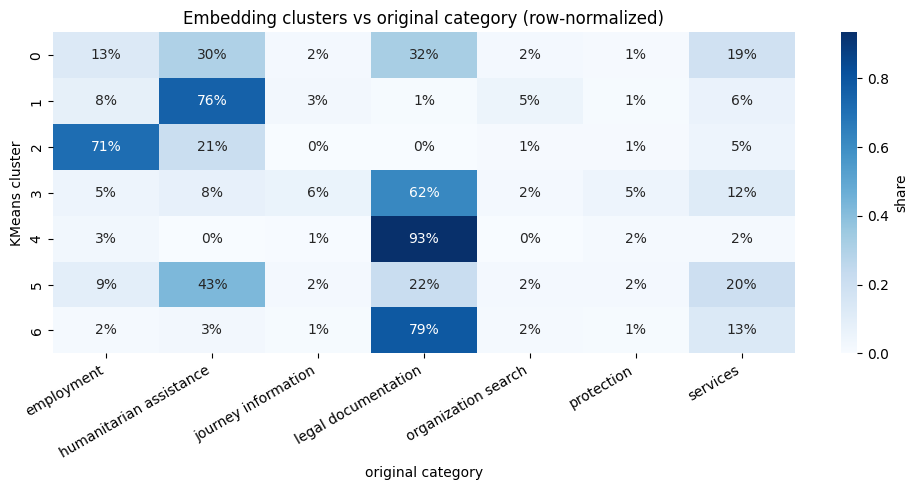

In [12]:
# Which original category dominates each embedding cluster? (row-normalized)
conf = pd.crosstab(user_docs.loc[known, "cluster_emb"],
                   user_docs.loc[known, "category"], normalize="index")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(conf, annot=True, fmt=".0%", cmap="Blues", ax=ax, cbar_kws={"label": "share"})
ax.set_title("Embedding clusters vs original category (row-normalized)")
ax.set_xlabel("original category"); ax.set_ylabel("KMeans cluster")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()

## 4. Emergent themes — what the taxonomy misses

**What this shows.** For each embedding cluster: its size, the original MMC
category that dominates it, that category's *purity* (share of users), and the
cluster's most distinctive lemmatized terms. A **low-purity** cluster is not
cleanly "explained" by any single official category — its vocabulary points at a
need the 7-category taxonomy does not name. Those are candidate **emergent
themes** (**H2**).

> **Technical note.** Purity here = share of the dominant MMC category within the
> cluster. The threshold (0.5) is a heuristic cut, not a statistical test; read
> the top terms to judge whether a low-purity cluster is a real theme or noise.

In [13]:
# Distinctive terms + dominant-category purity per embedding cluster.
terms = np.array(tfidf.get_feature_names_out())
rows = []
for c in range(K):
    m = (user_docs["cluster_emb"] == c).values
    centroid = np.asarray(X_tfidf[m].mean(axis=0)).ravel()
    top_terms = ", ".join(terms[centroid.argsort()[::-1][:8]])
    vc = user_docs.loc[m, "category"].value_counts()
    dom, pur = vc.index[0], vc.iloc[0] / vc.sum()
    rows.append({"cluster": c, "users": int(m.sum()), "dominant_category": dom,
                 "purity": round(float(pur), 2), "top_terms": top_terms})
themes = pd.DataFrame(rows).sort_values("purity").reset_index(drop=True)

PURITY_EMERGENT = 0.5   # below this, no single official category explains the cluster
themes["emergent"] = themes["purity"] < PURITY_EMERGENT
print(f"{int(themes['emergent'].sum())} candidate emergent cluster(s) "
      f"(purity < {PURITY_EMERGENT})")
themes

2 candidate emergent cluster(s) (purity < 0.5)


,cluster,users,dominant_category,purity,top_terms,emergent
0,0,140,legal documentation,0.32,"necesitar, salud, ayuda, querer, ayudar, yo, g...",True
1,5,55,humanitarian assistance,0.42,"humanitario, ayuda, gracias, medellín, empleo,...",True
2,3,103,legal documentation,0.60,"querer, visa, permiso, salvoconducto, requisit...",False
3,2,80,employment,0.71,"emprendimiento, empleo, ayuda, buscar, querer,...",False
4,1,111,humanitarian assistance,0.76,"ayuda, humanitario, querer, migrant, bogotá, r...",False
5,6,113,legal documentation,0.78,"ppt, sacar, querer, año, rumv, tutor, obtener,...",False
6,4,198,legal documentation,0.92,"colombia, colombiano, permiso, venezolano, ppt...",False


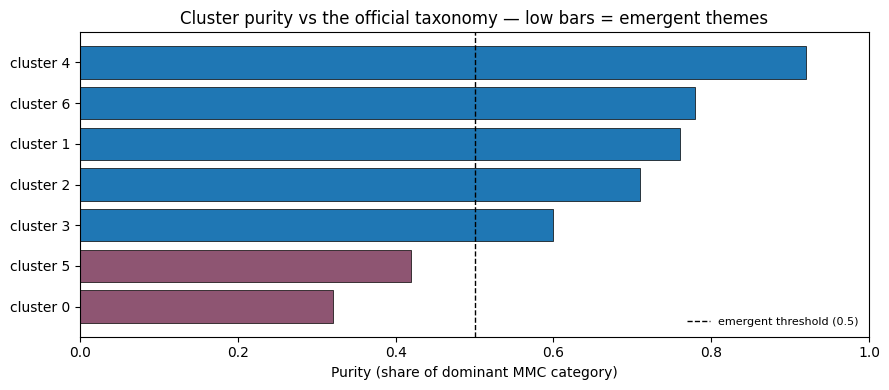

Candidate emergent themes (read the top terms):
  cluster 0 (n=140, purity 0.32): necesitar, salud, ayuda, querer, ayudar, yo, gracias, medellín
  cluster 5 (n=55, purity 0.42): humanitario, ayuda, gracias, medellín, empleo, informacion, refugio, asistencia


In [14]:
# Purity per cluster -- low bars (below the dashed line) are the emergent themes.
order = themes.sort_values("purity")
colors = [CAT_COLORS.get("emergent", NEGRO) if e else AGUA for e in order["emergent"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([f"cluster {c}" for c in order["cluster"]], order["purity"],
        color=colors, edgecolor=NEGRO, lw=.5)
ax.axvline(PURITY_EMERGENT, color=NEGRO, ls="--", lw=1, label=f"emergent threshold ({PURITY_EMERGENT})")
ax.set_xlim(0, 1)
ax.set_xlabel("Purity (share of dominant MMC category)")
ax.set_title("Cluster purity vs the official taxonomy — low bars = emergent themes")
ax.legend(fontsize=8, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print("Candidate emergent themes (read the top terms):")
for _, r in themes[themes["emergent"]].iterrows():
    print(f"  cluster {r['cluster']} (n={r['users']}, purity {r['purity']}): {r['top_terms']}")

## 5. Tinted embedding maps

*Project the 1024-d user embeddings to 2D/3D with **PCA** (visualization only —
KMeans used the full embeddings) and tint by original MMC category and by
KMeans cluster.*

In [15]:
# PCA to 3 components (deterministic, no extra dependency).
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
proj = pca.fit_transform(emb)
user_docs[["px", "py", "pz"]] = proj
print("explained variance (3 comps):", pca.explained_variance_ratio_.round(3),
      "-> total", float(pca.explained_variance_ratio_[:3].sum().round(3)))

explained variance (3 comps): [0.068 0.052 0.038] -> total 0.15800000727176666


### 5.1 Tinted by original MMC category

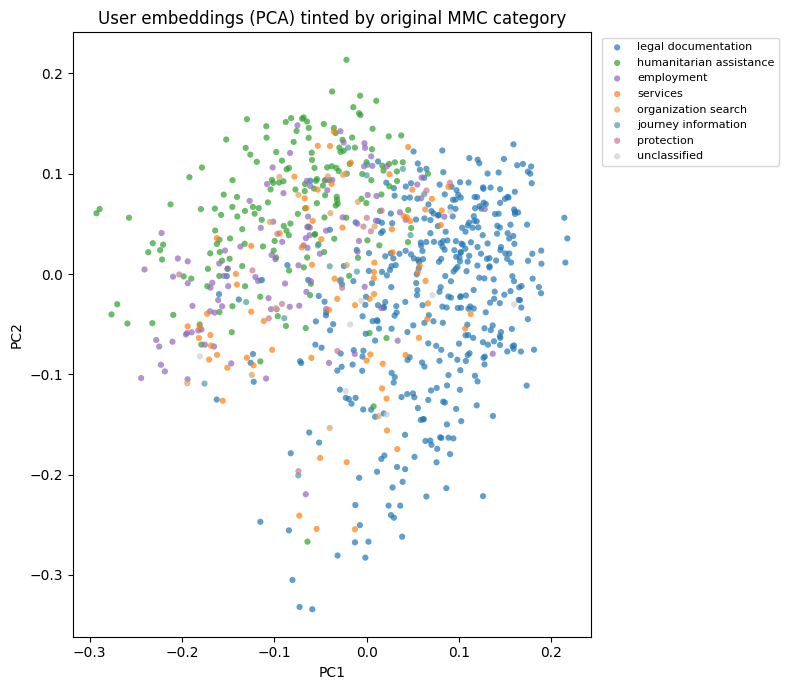

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
for cat in user_docs["category"].value_counts().index:
    m = user_docs["category"] == cat
    ax.scatter(user_docs.loc[m, "px"], user_docs.loc[m, "py"], s=20, alpha=.7,
               color=CAT_COLORS.get(cat, NEGRO), label=cat, edgecolor="none")
ax.set_title("User embeddings (PCA) tinted by original MMC category")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

### 5.2 Tinted by KMeans cluster

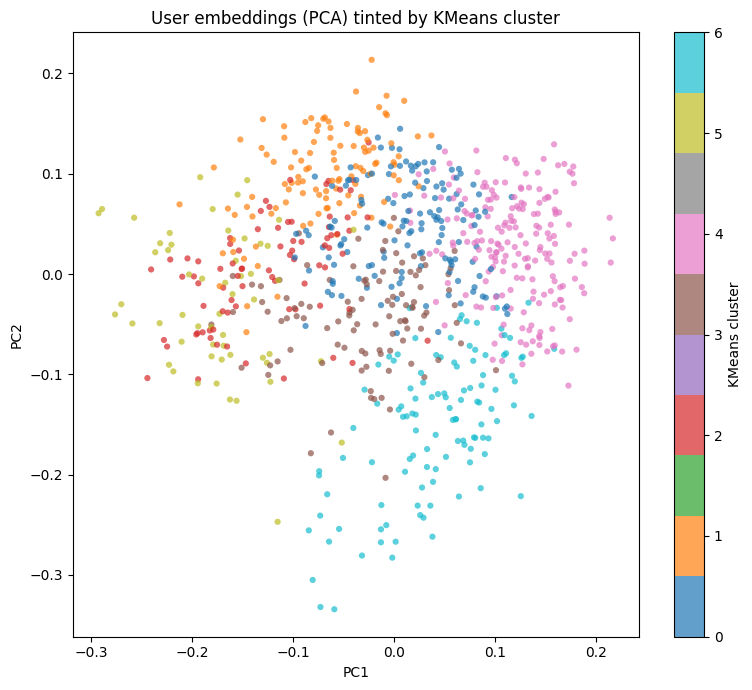

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(user_docs["px"], user_docs["py"], c=user_docs["cluster_emb"],
                cmap="tab10", s=20, alpha=.7, edgecolor="none")
ax.set_title("User embeddings (PCA) tinted by KMeans cluster")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="KMeans cluster")
plt.tight_layout()

### 5.3 Interactive 3D (Plotly) tinted by category

In [18]:
# Interactive 3D scatter of the PCA projection, tinted by original category.
import plotly.express as px

fig = px.scatter_3d(
    user_docs, x="px", y="py", z="pz", color="category",
    color_discrete_map={k: v for k, v in CAT_COLORS.items()},
    hover_data={"cluster_emb": True, "px": False, "py": False, "pz": False},
    title="User embeddings (PCA 3D) tinted by original MMC category")
fig.update_traces(marker=dict(size=3, opacity=0.8))
fig.update_layout(legend_title_text="MMC category", height=700)
fig.show()

## 6. Qualitative voices

**What this shows.** The users in their own words — a word cloud of the MEAL
recommendations and a thematic read of the substantive free-text comments.

> **Technical note.** The comments are user testimony in Spanish; they are shown
> verbatim (translating them would falsify the data). Only the chart framing is
> in English.

In [19]:
# MEAL survey (phone-keyed) -- source of the free-text recommendations.
_meal = load_meal()
print(f"MEAL responses: {len(_meal)}  |  with a recommendation: {_meal['recommendation'].notna().sum()}")

MEAL responses: 78  |  with a recommendation: 77


### 6.1 Word cloud of recommendations

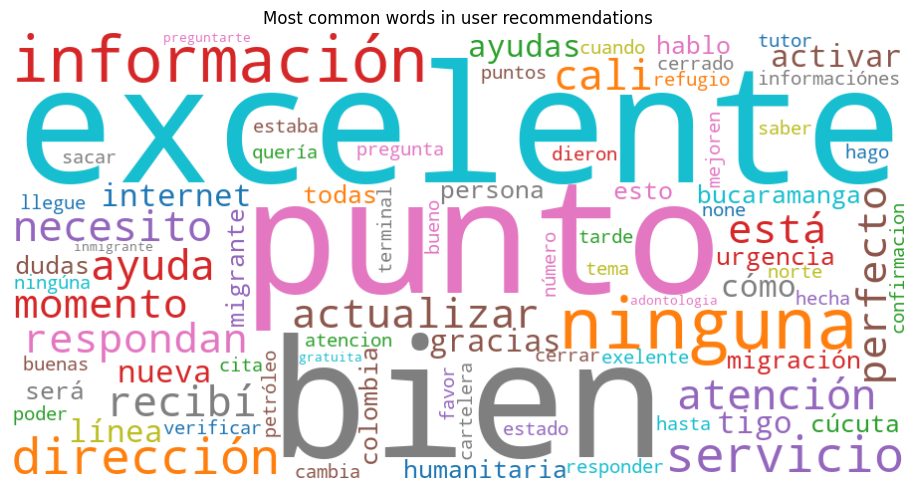

In [20]:
# Common Spanish stopwords to exclude so the cloud highlights meaningful themes.
ES_STOPWORDS = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'no', 'es', 'se', 'los', 'las',
    'con', 'por', 'un', 'una', 'para', 'más', 'del', 'al', 'lo', 'le', 'su',
    'me', 'mi', 'como', 'muy', 'pero', 'si', 'ya', 'este', 'esta', 'son', 'hay',
    'fue', 'ser', 'tiene', 'han', 'he', 'nos', 'sus', 'todo', 'también',
}
rec_text = _meal['recommendation'].dropna()
all_words = ' '.join(rec_text.str.lower()).split()
words = [w.strip('.,;:!?()\"\'') for w in all_words
         if len(w) > 3 and w.strip('.,;:!?()\"\'') not in ES_STOPWORDS]
word_freq = Counter(words)

# Colour words from the categorical palette so the cloud matches the notebook.
def _brand_color_func(word, font_size, position, orientation, random_state, **kwargs):
    return CAT[random_state.randint(0, len(CAT) - 1)]

wc = WordCloud(width=900, height=450, background_color=SURFACE,
               color_func=_brand_color_func, prefer_horizontal=0.9
               ).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most common words in user recommendations', fontsize=12)
plt.tight_layout()
plt.show()

### 6.2 Free-text recommendations (thematic read)

*Substantive comments only (non-answers such as "no" / "ninguna" filtered out).*

In [21]:
recs = _meal["recommendation"].dropna().astype(str)
recs = recs[~recs.str.strip().str.lower().isin(["no", "ninguna", "ninguno", "nada"])]
print(f"{len(recs)} substantive recommendations\n")
for t in recs.head(20):
    print("•", t)

42 substantive recommendations

• Excelente
• Ayuda, no se cómo activar mi línea nueva Tigo y mi internet
• No recibí ninguna información.
• No recibí información
• Todo bien gracias 😌🫂
• Ayudas en Bucaramanga
• Me necesito hablo con persona ! Esto es urgencia !!!!
• Será que hay un punto de atención para los migrante vía cali
• Que respondan todas las dudas
• Actualizar la dirección de Migración Colombia en Cúcuta
• Ayuda humanitaria
• Q dan informaciónes buenas
• Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos
• Poder responder a la pregunta hecha cuando cambia el tema
• necesito saber la dirección de un refugio en cali
• Si , actualizar la información
• Todo esta perfecto
• Perfecto
• El servicio es muy excelente
• No por el momento


## 7. Sentiment — an unsolicited distress signal

*3-class sentiment on every message; the tone users did not have to state
explicitly (**H3**).*

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

sentiment: {'negative': np.int64(480), 'neutral': np.int64(2302), 'positive': np.int64(211)} |  negative share: 16.0%


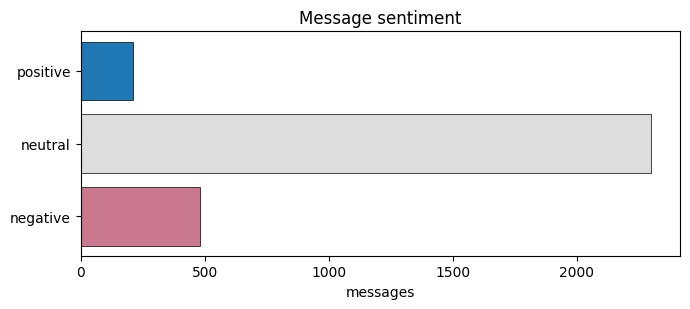

In [22]:
# 3-class sentiment per message.
from transformers import pipeline

texts = msgs["message"].astype(str).tolist()
sent_clf = pipeline("sentiment-analysis",
                    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
                    device=GPU, truncation=True, max_length=256)

def _norm_sent(label):
    l = label.lower()
    if "neg" in l or l.endswith("0"):
        return "negative"
    if "pos" in l or l.endswith("2"):
        return "positive"
    return "neutral"

preds = sent_clf([t[:256] for t in texts], batch_size=32)
msgs["sentiment"] = [_norm_sent(p["label"]) for p in preds]
del sent_clf
if DEVICE == "cuda":
    torch.cuda.empty_cache()

SENT_ORDER = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": "#c9788f", "neutral": HONGO, "positive": AGUA}
fig, ax = plt.subplots(figsize=(7, 3.2))
sd = msgs["sentiment"].value_counts().reindex(SENT_ORDER)
ax.barh(SENT_ORDER, sd.values, color=[SENT_COLORS[s] for s in SENT_ORDER],
        edgecolor=NEGRO, lw=.5)
ax.set_title("Message sentiment"); ax.set_xlabel("messages")
plt.tight_layout()
print("sentiment:", dict(sd), f"|  negative share: {sd['negative']/sd.sum()*100:.1f}%")

### 7.1 Sentiment by category

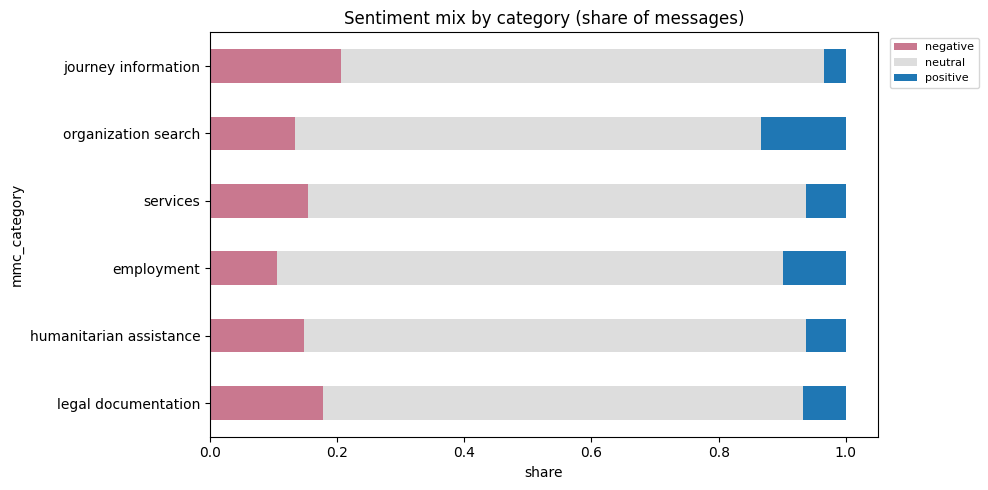

In [23]:
cats6 = (msgs[~msgs["mmc_category"].isin(NON_TOPIC_CATS)]["mmc_category"]
         .value_counts().head(6).index)
sub = msgs[msgs["mmc_category"].isin(cats6)]
tabS = (pd.crosstab(sub["mmc_category"], sub["sentiment"], normalize="index")
        .reindex(index=cats6, columns=SENT_ORDER, fill_value=0))
tabS.plot(kind="barh", stacked=True, figsize=(10, 5),
          color=[SENT_COLORS[s] for s in SENT_ORDER])
plt.title("Sentiment mix by category (share of messages)")
plt.xlabel("share"); plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 8. Geographic synthesis — need + tone by city

**The closer of the whole analysis (**H4**).** Per city: dominant need (MMC
category) and mean tone of its messages.

> One bubble per city (size = messages), ≥ 15 mapped messages; sentiment is mean
> polarity (−1 / 0 / +1); category is the most common per city.

In [24]:
# City coordinates + per-city aggregates. The map itself uses a contextily
# basemap (no floating shapefile) -- see _basemap() below.
import unicodedata
import contextily as cx

CITY_COORDS = {
    "bogota": (-74.0721, 4.7110),   "medellin": (-75.5812, 6.2442),
    "cali": (-76.5320, 3.4516),     "barranquilla": (-74.7813, 10.9685),
    "cartagena": (-75.4794, 10.3910),"cucuta": (-72.5078, 7.8939),
    "bucaramanga": (-73.1227, 7.1193),"maicao": (-72.2382, 11.3776),
    "riohacha": (-72.9072, 11.5449),"ipiales": (-77.6417, 0.8256),
    "santa marta": (-74.1990, 11.2408),"soacha": (-74.2168, 4.5794),
    "necocli": (-76.7889, 8.4245),
}
def _strip(s):
    s = str(s).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

msgs["city_key"] = msgs["city_canon"].map(_strip)
matched = msgs["city_key"].isin(CITY_COORDS)
print(f"{msgs.loc[matched,'city_key'].nunique()} cities mapped, "
      f"covering {matched.mean()*100:.0f}% of messages")

MIN_MSGS = 15
SENT_SIGN = {"negative": -1, "neutral": 0, "positive": 1}
gm = msgs[matched & ~msgs["mmc_category"].isin(NON_TOPIC_CATS)].copy()
gm["sent_sign"] = gm["sentiment"].map(SENT_SIGN)
geo = gm.groupby("city_key").agg(msgs_n=("city_key", "size"), sentiment=("sent_sign", "mean"))
geo = geo[geo["msgs_n"] >= MIN_MSGS]
geo["dominant"] = gm.groupby("city_key")["mmc_category"].agg(lambda s: s.value_counts().index[0])
geo["lon"] = [CITY_COORDS[c][0] for c in geo.index]
geo["lat"] = [CITY_COORDS[c][1] for c in geo.index]
geo["label"] = [c.title() for c in geo.index]
geo = geo.sort_values("msgs_n", ascending=False)

def _basemap(ax, title):
    "Frame Colombia and drop a light CartoDB Positron basemap behind the bubbles."
    ax.set_xlim(-80, -66); ax.set_ylim(-4.5, 13)
    ax.set_aspect("equal")
    cx.add_basemap(ax, crs="EPSG:4326", zorder=0,
                   source=cx.providers.CartoDB.PositronNoLabels, attribution_size=6)
    ax.set_title(title); ax.set_axis_off()
def _sizes(frame):
    return 60 + (frame["msgs_n"] / frame["msgs_n"].max()) * 900
print(f"{len(geo)} cities with >= {MIN_MSGS} messages mapped")
display(geo[["label", "msgs_n", "sentiment", "dominant"]].reset_index(drop=True))

13 cities mapped, covering 88% of messages
11 cities with >= 15 messages mapped


,label,msgs_n,sentiment,dominant
0,Medellin,1086,-0.076427,legal documentation
1,Bogota,483,-0.086957,legal documentation
2,Barranquilla,303,-0.033003,legal documentation
3,Cucuta,193,-0.139896,legal documentation
4,Ipiales,153,-0.052288,humanitarian assistance
5,Santa Marta,141,-0.156028,legal documentation
6,Soacha,130,-0.092308,legal documentation
7,Maicao,41,-0.170732,legal documentation
8,Cali,30,-0.166667,organization search
9,Bucaramanga,22,0.045455,humanitarian assistance


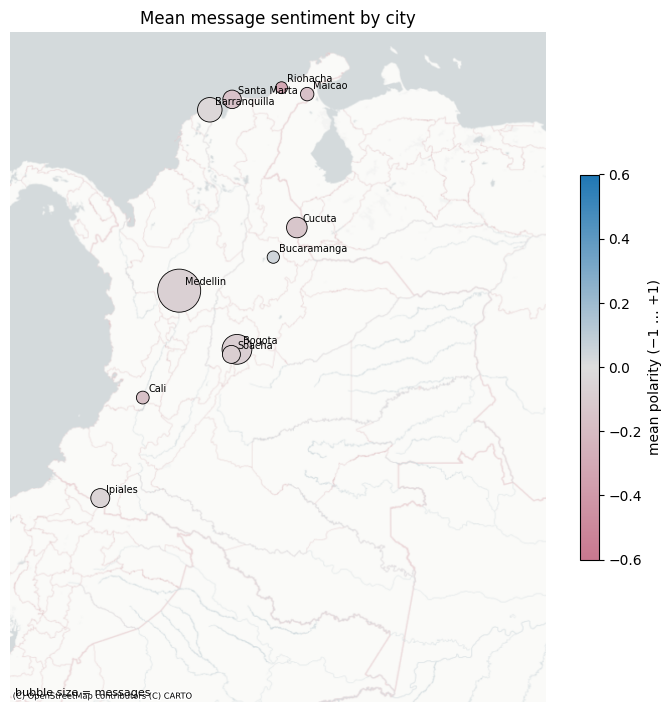

In [25]:
from matplotlib.colors import LinearSegmentedColormap
sent_cmap = LinearSegmentedColormap.from_list("mmc_sent", ["#c9788f", HONGO, AGUA])
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Mean message sentiment by city")
sc = ax.scatter(geo["lon"], geo["lat"], s=_sizes(geo), c=geo["sentiment"],
                cmap=sent_cmap, vmin=-0.6, vmax=0.6, edgecolor=NEGRO, lw=.6, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
cbar = plt.colorbar(sc, ax=ax, shrink=0.5); cbar.set_label("mean polarity (−1 … +1)")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()

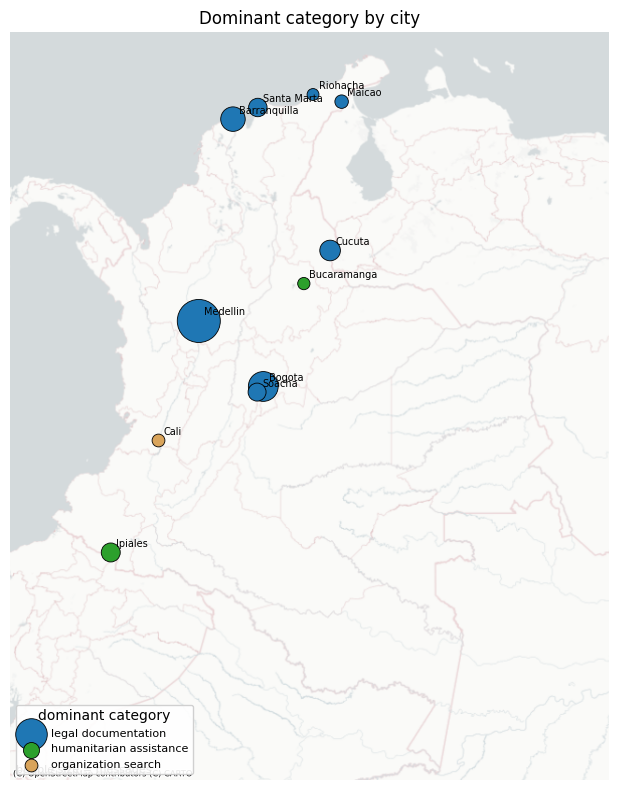

In [26]:
fig, ax = plt.subplots(figsize=(7, 8))
_basemap(ax, "Dominant category by city")
sizes = _sizes(geo)
for cat in geo["dominant"].unique():
    m = geo["dominant"] == cat
    ax.scatter(geo.loc[m, "lon"], geo.loc[m, "lat"], s=sizes[m],
               color=CAT_COLORS.get(cat, NEGRO), edgecolor=NEGRO, lw=.6, label=cat, zorder=2)
for _, r in geo.iterrows():
    ax.annotate(r["label"], (r["lon"], r["lat"]), fontsize=7, xytext=(4, 4),
                textcoords="offset points")
ax.legend(loc="lower left", fontsize=8, framealpha=.9, title="dominant category")
ax.text(0.01, 0.01, "bubble size = messages", transform=ax.transAxes, fontsize=8)
plt.tight_layout()